In [64]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import SBM.utils.utils as ut

In [60]:
entries = []

for model_folder in glob.glob("../models/SectorShuffling_SubAln*"):
    subaln_index = int(model_folder.split("_")[1][6:])
    shuffle_index = model_folder.split("_")[3][3:]
    if shuffle_index == "huffle":
        shuffle_index = 0
    else:
        shuffle_index = int(shuffle_index)
    
    model_file = glob.glob(model_folder + "/*N_chains75_N_iter1000_Param_initzero_k_MCMC5000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy")[0]
    entry = {
        'subaln_index': subaln_index,
        'shuffle_index': shuffle_index,
        'model_file': model_file
    }
    entries.append(entry)
    
df = pd.DataFrame(entries).sort_values(["shuffle_index", "subaln_index"]).set_index(["shuffle_index", "subaln_index"])

In [61]:
def compensatory_ddes(J):
    # returns all the DDEs for compensating the D189S insertion on C.T.
    DDEs = -J[1,3,16,:] + np.outer(J[1,3,16,6], np.ones(21)) + J[1,3,3,:] - np.outer(J[1,3,3,6], np.ones(21))
    return DDEs

../models/SectorShuffling_SubAln0_Step00_noshuffle/SectorShuffling_SubAln0_Step00_noshuffle_ModelSBM_N_chains75_N_iter1000_Param_initzero_k_MCMC5000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


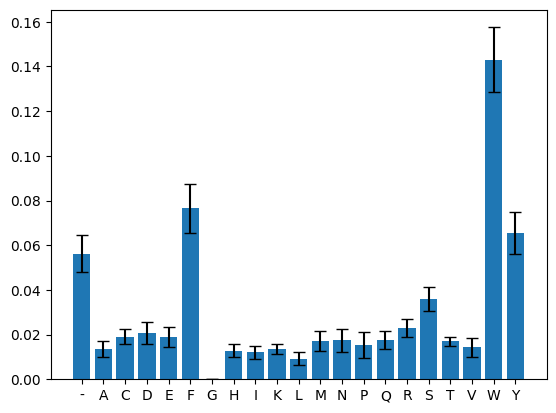

../models/SectorShuffling_SubAln1_Step00_noshuffle/SectorShuffling_SubAln1_Step00_noshuffle_ModelSBM_N_chains75_N_iter1000_Param_initzero_k_MCMC5000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


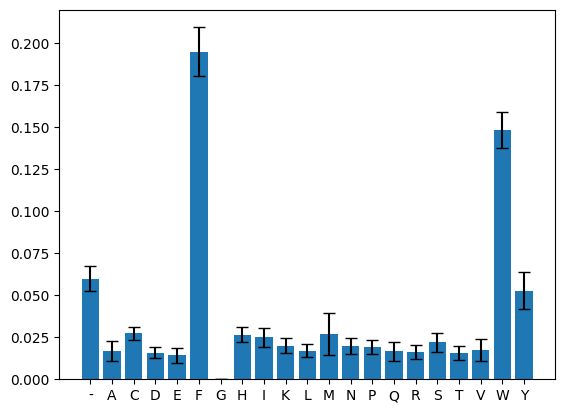

../models/SectorShuffling_SubAln2_Step00_noshuffle/SectorShuffling_SubAln2_Step00_noshuffle_ModelSBM_N_chains75_N_iter1000_Param_initzero_k_MCMC5000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


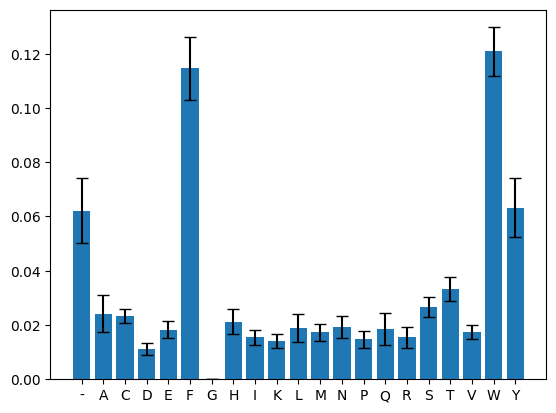

../models/SectorShuffling_SubAln3_Step00_noshuffle/SectorShuffling_SubAln3_Step00_noshuffle_ModelSBM_N_chains75_N_iter1000_Param_initzero_k_MCMC5000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


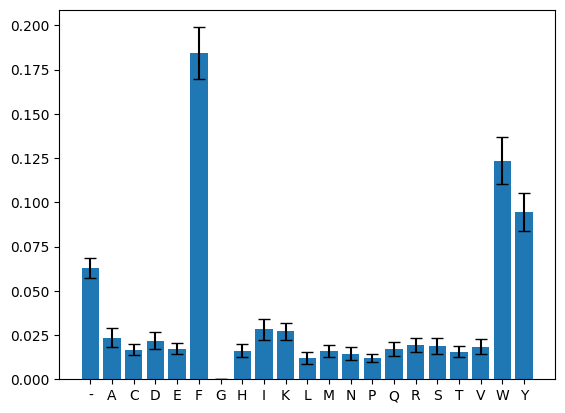

../models/SectorShuffling_SubAln4_Step00_noshuffle/SectorShuffling_SubAln4_Step00_noshuffle_ModelSBM_N_chains75_N_iter1000_Param_initzero_k_MCMC5000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


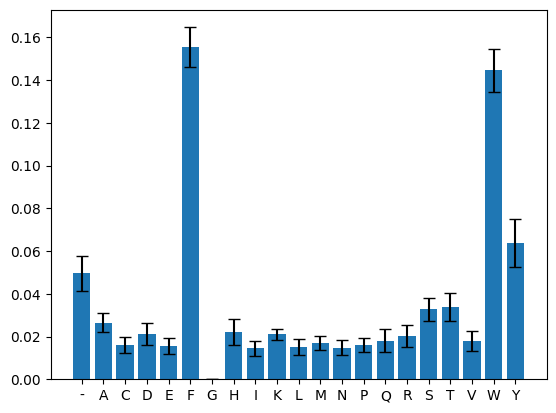

../models/SectorShuffling_SubAln5_Step00_noshuffle/SectorShuffling_SubAln5_Step00_noshuffle_ModelSBM_N_chains75_N_iter1000_Param_initzero_k_MCMC5000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


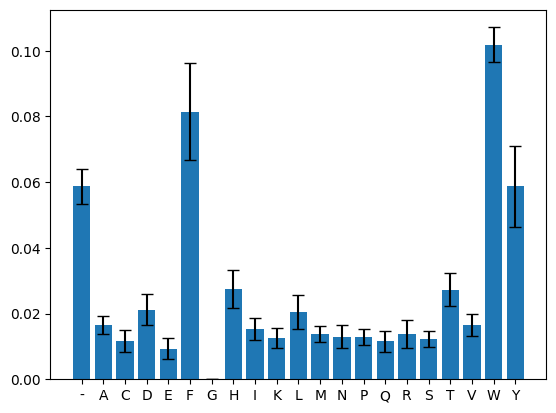

../models/SectorShuffling_SubAln6_Step00_noshuffle/SectorShuffling_SubAln6_Step00_noshuffle_ModelSBM_N_chains75_N_iter1000_Param_initzero_k_MCMC5000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


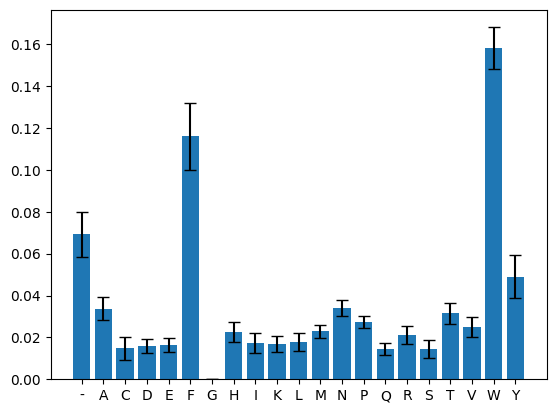

../models/SectorShuffling_SubAln7_Step00_noshuffle/SectorShuffling_SubAln7_Step00_noshuffle_ModelSBM_N_chains75_N_iter1000_Param_initzero_k_MCMC5000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


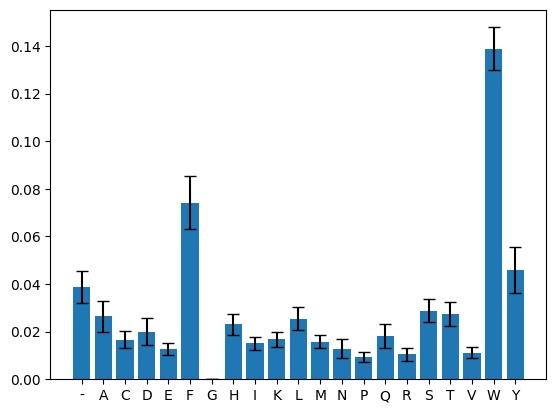

../models/SectorShuffling_SubAln8_Step00_noshuffle/SectorShuffling_SubAln8_Step00_noshuffle_ModelSBM_N_chains75_N_iter1000_Param_initzero_k_MCMC5000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


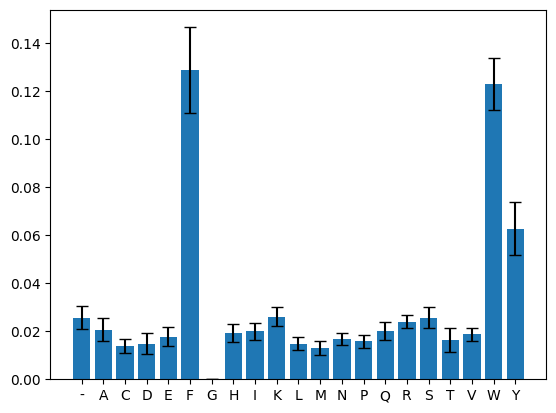

../models/SectorShuffling_SubAln9_Step00_noshuffle/SectorShuffling_SubAln9_Step00_noshuffle_ModelSBM_N_chains75_N_iter1000_Param_initzero_k_MCMC5000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


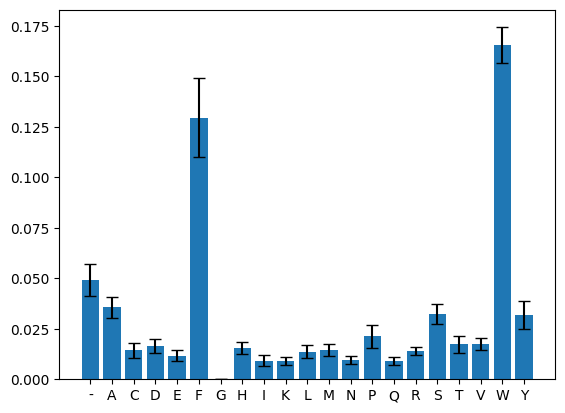

In [90]:
for f in df.loc[0, :].model_file:
    print(f)
    plt.figure()
    model = np.load(f, allow_pickle=True).item()
    Js_for_paramset = []
    for W_all in model["W_all"]:
        J, h = ut.Jw(W_all, q=21)
        Js_for_paramset.append(np.abs(compensatory_ddes(J).ravel()))
    plt.bar(
        np.arange(21),
        np.mean(Js_for_paramset, axis=0),
        yerr=np.std(Js_for_paramset, axis=0) / np.sqrt(10),
        capsize=4
    )
    plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
    plt.show()

In [ ]:
np.load(, allow_pickle=True)